# Chapter 20 — Adaptive Query Execution (AQE) in Apache Spark

In this chapter, we explore **Adaptive Query Execution (AQE)**, introduced and enabled by default in Apache Spark 3.x. In traditional Spark (Spark 1.x and 2.x), query optimization was strictly **static** — Catalyst generated a physical execution plan before the job started, guessing partition sizes and join strategies based on raw file metadata. When data was filtered, aggregated, or skewed, static plans often resulted in severe performance bottlenecks.

**AQE revolutionizes query execution by re-optimizing the query plan at runtime using actual stage shuffle statistics.**

We will explore the three core pillars of AQE hands-on:
1. **Dynamically Coalescing Post-Shuffle Partitions** (`spark.sql.adaptive.coalescePartitions.enabled`) — automatically combining small or empty partitions into balanced tasks.
2. **Dynamically Handling Data Skew** (`spark.sql.adaptive.skewJoin.enabled`, `skewedPartitionThresholdInBytes`) — splitting oversized, skewed partitions into parallel sub-partitions without requiring manual salting.
3. **Dynamically Converting Sort-Merge Join to Broadcast Join** (`spark.sql.autoBroadcastJoinThreshold`) — converting expensive SortMergeJoins into fast BroadcastHashJoins when intermediate table sizes drop below the threshold.

---


In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder.appName("AQE in spark").master("spark://4619b568af8b:7077")
    .config("spark.cores.max",8)
    .config("spark.executor.cores",4)
    .config("spark.executor.memmory","512M")
    .getOrCreate()
)
spark

#### ☝️ Creating the SparkSession on our Cluster

In this session configuration:
- `spark.cores.max = 8`: Allocates up to 8 CPU cores across our cluster.
- `spark.executor.cores = 4`: Each executor gets 4 CPU cores (yielding 2 executors total: 8 / 4 = 2).
- `spark.executor.memory = 512M`: Allocates 512 MB memory per executor.

In Spark 3.0+, AQE is enabled by default (`spark.sql.adaptive.enabled = true`). To see why AQE is so critical, we will first disable it completely to establish a baseline.

---


In [2]:
# Disable AQE and Broadcast join
spark.conf.set("spark.sql.adaptive.enabled", False)
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", False)
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1) # this will make sure that spark will not automatically broadcast the smaller dataset

#### ☝️ Baseline Setup — Disabling AQE and Automatic Broadcast

Here we turn off all adaptive optimizations:
1. `spark.sql.adaptive.enabled = False`: Turns off the entire AQE runtime engine.
2. `spark.sql.adaptive.coalescePartitions.enabled = False`: Prevents Spark from coalescing small shuffle partitions.
3. `spark.sql.autoBroadcastJoinThreshold = -1`: Sets the threshold to `-1` so Spark cannot broadcast `dept`, even though it is tiny.

With these flags disabled, Spark runs in **static execution mode**, exactly like Spark 2.x.

---


## 📝 1. Static Planning vs Adaptive Query Execution (AQE)

**In traditional Spark, physical execution plans are fixed before any task runs.**

```text
┌──────────────────────────────────────────────────────────────────┐
│                   STATIC PLANNING (Spark 2.x)                    │
│                                                                  │
│  DataFrame / SQL Code                                            │
│        │                                                         │
│        ▼                                                         │
│  Catalyst Optimizer ───> Static Physical Plan ───> Runs Blindly  │
│  (Guesses stats before execution)                  (No changes!) │
└──────────────────────────────────────────────────────────────────┘
                                 vs
┌──────────────────────────────────────────────────────────────────┐
│              ADAPTIVE QUERY EXECUTION (Spark 3.x)                │
│                                                                  │
│  DataFrame / SQL Code                                            │
│        │                                                         │
│        ▼                                                         │
│  Stage 1 Runs ───> Shuffle Files Written ───> Real Stats Known   │
│                                                      │           │
│  Stage 2 Re-optimized! <─── Adaptive Engine <────────┘           │
│  (Coalesce partitions, split skews, convert join type)           │
└──────────────────────────────────────────────────────────────────┘
```

What the diagram is saying, step by step:
1. **The Static Dilemma:** Before running a query, Catalyst estimates sizes based on table metadata. But after complex filters or joins, intermediate data sizes change dramatically. Catalyst cannot know the actual sizes until the data is actually computed.
2. **Shuffle Materialization as Feedback Points:** Shuffling breaks a query into separate stages. When Stage 1 tasks finish, their output is materialized (written to shuffle files on disk).
3. **Runtime Re-Planning:** AQE pauses execution between stages, inspects the exact shuffle file sizes and row counts, and re-optimizes the physical plan for Stage 2 before launching tasks!

---


In [3]:
# Read Employee data
_schema = "first_name string, last_name string, job_title string, dob string, email string, phone string, salary double, department_id int"
emp = spark.read.format("csv").schema(_schema).option("header", True).load("/data/csv/employee_records.csv")

In [4]:
# Read DEPT CSV data
_dept_schema = "department_id int, department_name string, description string, city string, state string, country string"
dept = spark.read.format("csv").schema(_dept_schema).option("header", True).load("/data/csv/department_data.csv")

#### ☝️ Loading Employee Records and Department Data

We load our datasets with explicit schemas:
- `emp`: Contains hundreds of thousands of employee records. Crucially, as we saw in Chapter 19, specific department keys (like `department_id = 1`) have massive row counts, creating severe data skew.
- `dept`: A small lookup dimension table containing 10 department records.

---


In [5]:
# Join Datasets
df_joined = emp.join(dept, on=emp.department_id==dept.department_id, how="left_outer")

In [6]:
df_joined.explain()
# since we disabled the broadcast join.The SortMergeJoin will happen

== Physical Plan ==
*(4) SortMergeJoin [department_id#7], [department_id#16], LeftOuter
:- *(1) Sort [department_id#7 ASC NULLS FIRST], false, 0
:  +- Exchange hashpartitioning(department_id#7, 200), ENSURE_REQUIREMENTS, [id=#17]
:     +- FileScan csv [first_name#0,last_name#1,job_title#2,dob#3,email#4,phone#5,salary#6,department_id#7] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/data/csv/employee_records.csv], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<first_name:string,last_name:string,job_title:string,dob:string,email:string,phone:string,s...
+- *(3) Sort [department_id#16 ASC NULLS FIRST], false, 0
   +- Exchange hashpartitioning(department_id#16, 200), ENSURE_REQUIREMENTS, [id=#29]
      +- *(2) Filter isnotnull(department_id#16)
         +- FileScan csv [department_id#16,department_name#17,description#18,city#19,state#20,country#21] Batched: false, DataFilters: [isnotnull(department_id#16)], Format: CSV, Location: InMem

#### ☝️ Physical Plan Analysis — SortMergeJoin and 200 Shuffle Partitions

In the physical plan above:
1. **`SortMergeJoin [department_id#7], [department_id#16], LeftOuter`**: Because broadcast join was disabled, Spark must sort and merge both datasets.
2. **`Exchange hashpartitioning(..., 200)`**: Both `emp` and `dept` are shuffled across the default 200 shuffle partitions (`spark.sql.shuffle.partitions = 200`).
3. **Static Guesses**: Spark has no idea that `dept` only has 10 rows or that `emp` has severe skew on certain departments — it blindly creates 200 shuffle partitions for both sides.

---


In [7]:
df_joined.write.format("noop").mode("overwrite").save()

## 📝 2. Observations from Spark UI — The Cost of Disabled AQE

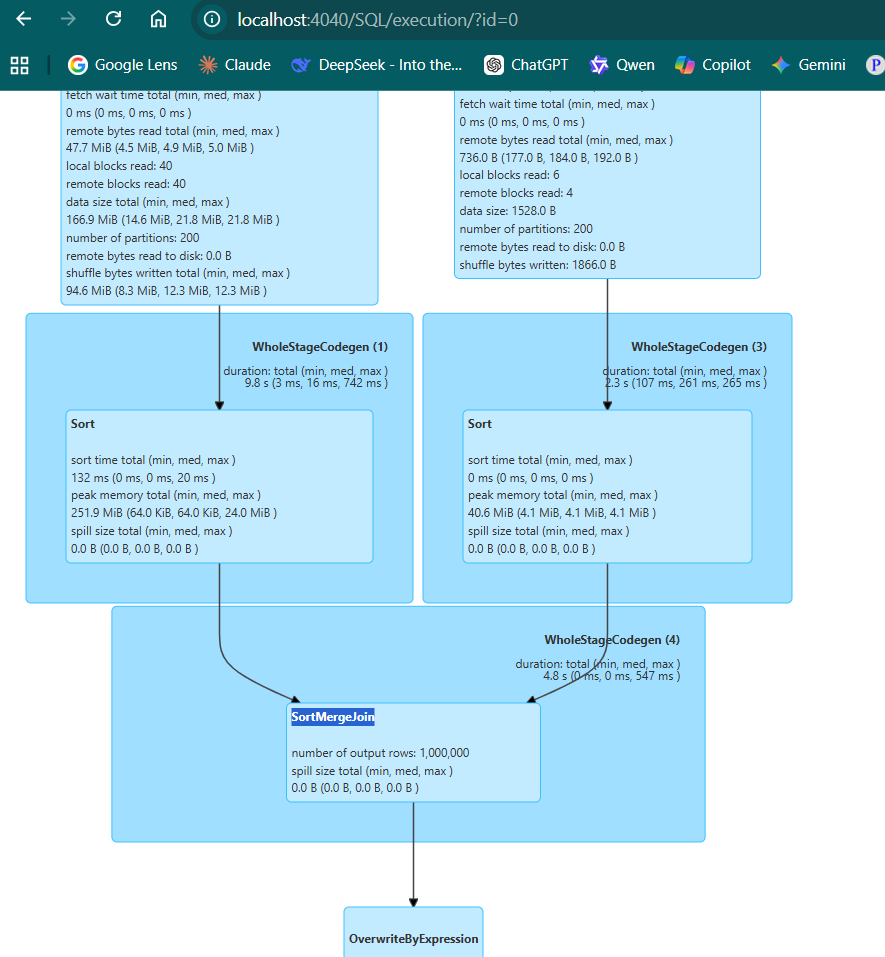

#### ☝️ Screenshot 1: Spark UI DAG — Sort-Merge Join with 200 Partitions on Both Sides

In the DAG visualization for the query plan (`localhost:4040/SQL/execution/?id=0`):
1. **Forced 200 Partitions on the Tiny Dept Table:** Look at the right branch for `dept`. Even though `dept` contains only **1,528 bytes (10 rows)**, Spark blindly created **200 shuffle partitions** (`number of partitions: 200`) because `spark.sql.shuffle.partitions` defaults to 200!
2. **Forced 200 Partitions on Employee:** The left branch for `emp` (166.9 MiB) was also split into 200 partitions (`shuffle bytes written: 94.6 MiB`).
3. **Double Sort Step:** Both sides are forced through `WholeStageCodegen (1)` and `WholeStageCodegen (3)` to sort the partitions on `department_id`.
4. **SortMergeJoin Execution:** Reaching `WholeStageCodegen (4)`, Spark performs a SortMergeJoin to produce 1,000,000 output rows.

---


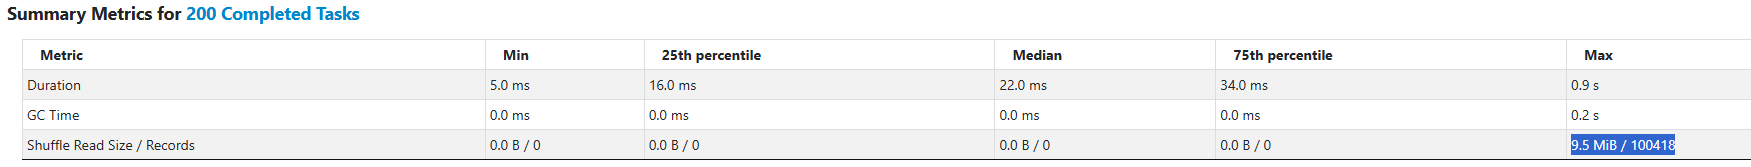

#### ☝️ Screenshot 2: Summary Metrics for 200 Completed Tasks — 190 Empty Partitions!

In the Summary Metrics distribution table for the 200 shuffle tasks:
1. **0 Bytes and 0 Records Across 75% of Tasks:** Look at the `Shuffle Read Size / Records` row:
   - **Min:** `0.0 B / 0`
   - **25th percentile:** `0.0 B / 0`
   - **Median:** `0.0 B / 0`
   - **75th percentile:** `0.0 B / 0`
2. **Only the Max Task Did Substantial Work:** The **Max** task read **9.5 MiB / 100,418 records**!
3. **The Overhead:** Because `department_id` values only populate a small number of hash buckets, over **190 partitions were completely empty**. Yet Spark still launched 190 separate tasks, wasting driver scheduling time, thread allocations, and network handshakes.

---


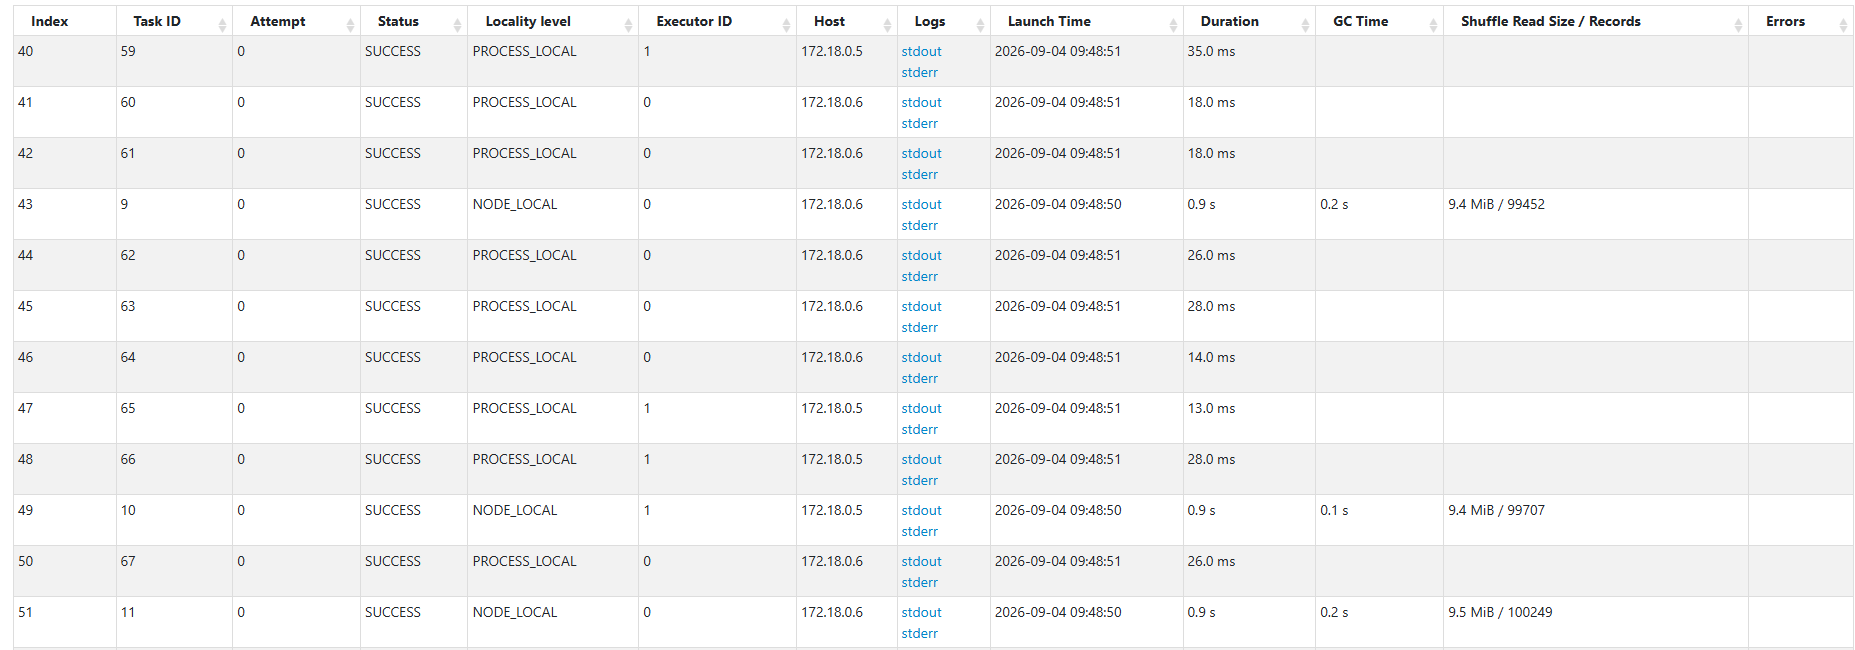

#### ☝️ Screenshot 3: Task Details Table — Straggler Tasks vs. Millisecond Empty Tasks

In the individual task execution details:
1. **Instant Empty Tasks (e.g. Tasks 59, 60, 61, 62, 63, 64, 65, 66):** Finished in **13 ms to 35 ms** having read `0 bytes` and `0 records`.
2. **Heavy Straggler Tasks (e.g. Tasks 9, 10, 11):** Each took **0.9 seconds** to complete, processing **9.4 MiB to 9.5 MiB (around ~100,000 records each)**.
3. **The Cluster Bottleneck:** Spark stages operate under barrier synchronization — the job cannot move forward until the last task finishes. The entire cluster waits on these few skewed tasks while most executor cores sit completely idle.

---


In [8]:
# Coalescing post-shuffle partitions - remove un-necessary shuffle partitions
# Skewed join optimization (balance partitions size) - join smaller partitions and split bigger partition
spark.conf.set("spark.sql.adaptive.enabled", True)
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", True)

#### ☝️ Enabling AQE and Dynamic Partition Coalescing

We enable the first two components of AQE:
- `spark.sql.adaptive.enabled = True`: Turns on the adaptive runtime engine.
- `spark.sql.adaptive.coalescePartitions.enabled = True`: Instructs Spark to dynamically merge small or empty shuffle partitions after Stage 1 shuffle files are written.

Instead of running 200 separate tasks, Spark will dynamically calculate the target partition size and coalesce contiguous small partitions into a single task.

---


In [9]:
# Fix partition sizes to avoid Skew
spark.conf.set("spark.sql.adaptive.advisoryPartitionSizeInBytes", "8MB") #Default value: 64MB
# spark.sql.adaptive.advisoryPartitionSizeInBytes
# The size in bytes of the shuffle partition during adaptive optimization.
# This can control the size of shuffle partitions post-shuffle.
# Now that out task partition memory is small we will make the partitions smaller in size to 8MB (Note: likely intended as "our task partition memory")

spark.conf.set("spark.sql.adaptive.skewJoin.skewedPartitionThresholdInBytes", "10MB") #Default value: 256MB
# spark.sql.adaptive.skewJoin.skewedPartitionThresholdInBytes
# A partition is considered as skewed if its size in bytes is larger than this threshold.
# The mentioned configuration for partitions sizes are configured for the mentioned job. Please check it properly before you configure it for any production jobs.
# But now you know how to fix skew partitions with Spark configs provided with AQE

## 📝 3. Configuring AQE Partition Sizing and Skew Join Thresholds

#### ☝️ Understanding the Two Key AQE Tuning Configurations

> **Your Notes & Configurations:**
> - `spark.sql.adaptive.advisoryPartitionSizeInBytes`: Target partition size in bytes during adaptive optimization. Controls the size of shuffle partitions post-shuffle. Default value: `64MB`. Here set to `"8MB"`.
> - `spark.sql.adaptive.skewJoin.skewedPartitionThresholdInBytes`: A partition is considered skewed if its size in bytes is larger than this threshold. Default value: `256MB`. Here set to `"10MB"`.
> - *Note: The mentioned configuration for partition sizes are configured for this specific demonstration job. Please check and benchmark properly before configuring them for production jobs!*

```text
┌──────────────────────────────────────────────────────────────────┐
│                HOW AQE AUTOMATICALLY HANDLES SKEW                │
├──────────────────────────────────────────────────────────────────┤
│ 1. BEFORE AQE (The Problem):                                     │
│    Partition 0 (2 MB)  ───> Core 1 (Finishes in 1s)              │
│    Partition 1 (45 MB) ───> Core 2 (SKEW! Spills to disk, 60s)   │
│    Partition 2 (1 MB)  ───> Core 3 (Finishes in 1s)              │
│                                                                  │
│ 2. AQE RUNTIME DETECTION:                                        │
│    Partition 1 size (45 MB) > skewedPartitionThreshold (10 MB)   │
│    ---> Flagged as SKEWED!                                       │
│                                                                  │
│ 3. AFTER AQE (Dynamic Split):                                    │
│    Partition 1 split into ~8 MB chunks (advisoryPartitionSize)   │
│    Part 1_0 (8 MB) ───> Core 1                                   │
│    Part 1_1 (8 MB) ───> Core 2   All cores work in parallel!     │
│    Part 1_2 (8 MB) ───> Core 3   No disk spillage!               │
│    Part 1_3 (8 MB) ───> Core 4                                   │
└──────────────────────────────────────────────────────────────────┘
```

What happens under the hood:
1. **Dynamic Skew Detection:** A partition is treated as skewed if its size exceeds `skewedPartitionThresholdInBytes` (default 256MB, set to 10MB here) AND is at least `spark.sql.adaptive.skewJoin.skewedPartitionFactor` (default 5x) larger than the median partition size.
2. **Automatic Sub-Partition Splitting:** When a skewed partition is detected, AQE automatically splits it into multiple smaller sub-partitions, each sized around `advisoryPartitionSizeInBytes` (8MB).
3. **Zero Manual Code Changes:** In Chapter 19, solving skew required the complex Salting technique (generating random salt keys with a UDF, replicating the lookup table with a Cartesian cross join, and joining on composite keys). With AQE, **Spark splits the skewed partition dynamically behind the scenes without touching user code!**

---


In [10]:
# Join Datasets - without specifying specific broadcast table
df_joined = emp.join(dept, on=emp.department_id==dept.department_id, how="left_outer")
df_joined.write.format("noop").mode("overwrite").save()

## 📝 4. Result: Skew Eliminated Without Manual Salting!

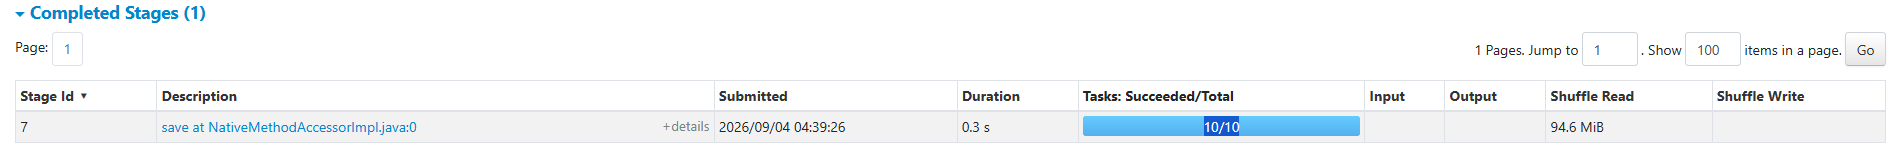

#### ☝️ Screenshot 1: Spark UI Stages — 200 Partitions Coalesced into Exactly 10 Tasks!

Looking at the Stage summary (`Stage Id 7`):
1. **Tasks: Succeeded/Total = 10/10:** Previously, Spark launched **200 tasks**. With AQE partition coalescing enabled, Spark inspected the shuffle files at the stage boundary, identified the empty partitions, and **dynamically coalesced the stage down to only 10 tasks**!
2. **Total Stage Duration: 0.3 s:** The total stage duration dropped to just 300 ms because 190 useless empty tasks were never scheduled.
3. **Shuffle Read: 94.6 MiB:** The exact same 94.6 MiB of employee shuffle data was transferred, but cleanly packaged into only 10 tasks instead of 200.

---


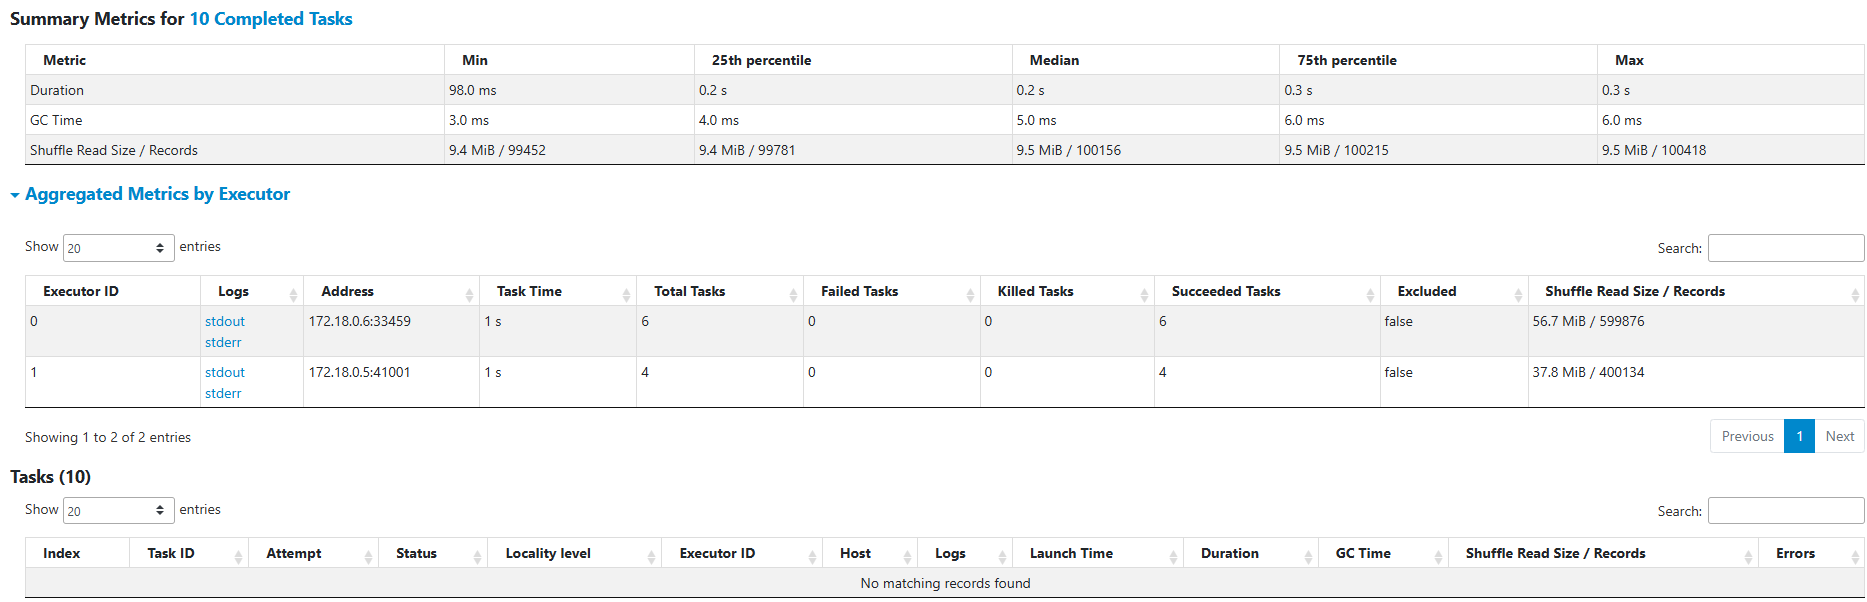

> **Your Observation:**
> *"There is no skewed data and previously we need to go through salting for fixing this. Here it's not required."*

#### ☝️ Screenshot 2: Summary Metrics & Executor Balance — Perfectly Balanced Execution

In the Summary Metrics for the 10 completed tasks:
1. **Uniform Task Durations:**
   - **Min:** `98.0 ms`
   - **Median:** `0.2 s`
   - **Max:** `0.3 s`
   There are no stragglers! Every task finished in nearly the exact same amount of time.
2. **Evenly Distributed Rows Across All Tasks:**
   - **Min:** `9.4 MiB / 99,452 rows`
   - **Median:** `9.5 MiB / 100,156 rows`
   - **Max:** `9.5 MiB / 100,418 rows`
   Every single task processed ~100,000 records. The skew was completely neutralized!
3. **Aggregated Metrics by Executor:**
   - **Executor 0:** Processed 6 tasks (`56.7 MiB / 599,876 records`) in 1s total task time.
   - **Executor 1:** Processed 4 tasks (`37.8 MiB / 400,134 records`) in 1s total task time.
4. **AQE vs. Manual Salting:**
   - **Chapter 19 (Salting):** Required defining a random salt UDF, replicating the dimension table by 32x with a Cartesian Cross Join, and joining on composite keys.
   - **Chapter 20 (AQE):** Spark did all of this automatically at runtime using `skewJoin.enabled` and `advisoryPartitionSizeInBytes` — zero code changes required!

---


In [13]:
# Converting sort-merge join to broadcast join
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "10MB")

#### ☝️ Pillar 3 — Dynamically Converting Sort-Merge Join to Broadcast Join

Here we set `spark.sql.autoBroadcastJoinThreshold` to `"10MB"`:
- *(Note: Spark requires unit strings without spaces, like `"10MB"` or `"10m"`, otherwise `IllegalArgumentException` is raised.)*

**How AQE Dynamically Converts Joins:**
- When two tables are joined, static Catalyst planning checks initial table sizes. If a table appears larger than 10MB on disk, Spark statically selects a Sort-Merge Join (or Shuffle Hash Join).
- But if that table undergoes filtering, aggregation, or column pruning during earlier stages, its actual size in memory may shrink to just a few kilobytes!
- **With AQE:** At the shuffle boundary, Spark inspects the materialized shuffle bytes. If one side's runtime size is below `autoBroadcastJoinThreshold`, AQE **dynamically downgrades the Sort-Merge Join to a Broadcast Hash Join (BHJ)**.
- This eliminates the need to shuffle the other side altogether!

---


In [14]:
# Join Datasets
df_joined = emp.join(dept, on=emp.department_id==dept.department_id, how="left_outer")
df_joined.write.format("noop").mode("overwrite").save()

## 📝 5. Verification — Dynamic Broadcast Hash Join in Spark UI

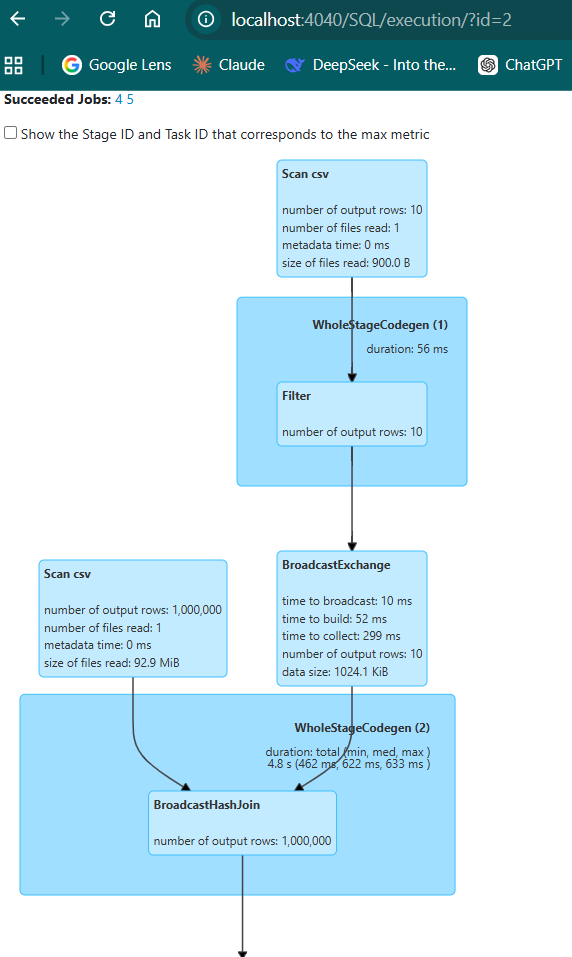

#### ☝️ Screenshot 1: Spark UI DAG — Sort-Merge Join Replaced by BroadcastHashJoin

In the execution DAG (`localhost:4040/SQL/execution/?id=2`):
1. **`BroadcastExchange` on `dept`:** Spark scanned the 10 rows of `dept` (900.0 B) and created a `BroadcastExchange` (`time to broadcast: 10 ms`, `data size: 1024.1 KiB`).
2. **Zero Shuffle on the 1,000,000-Row Employee Table:** Look at the left branch for `emp`. It reads 1,000,000 rows (92.9 MiB) and connects **directly** into `WholeStageCodegen (2)`! There is no `Exchange` (no shuffle write, no shuffle read, and no sort).
3. **`BroadcastHashJoin` Executed:** Even though our code did not include `broadcast(dept)`, AQE inspected the runtime size of `dept` at the stage boundary and dynamically converted the join strategy to Broadcast Hash Join.

---


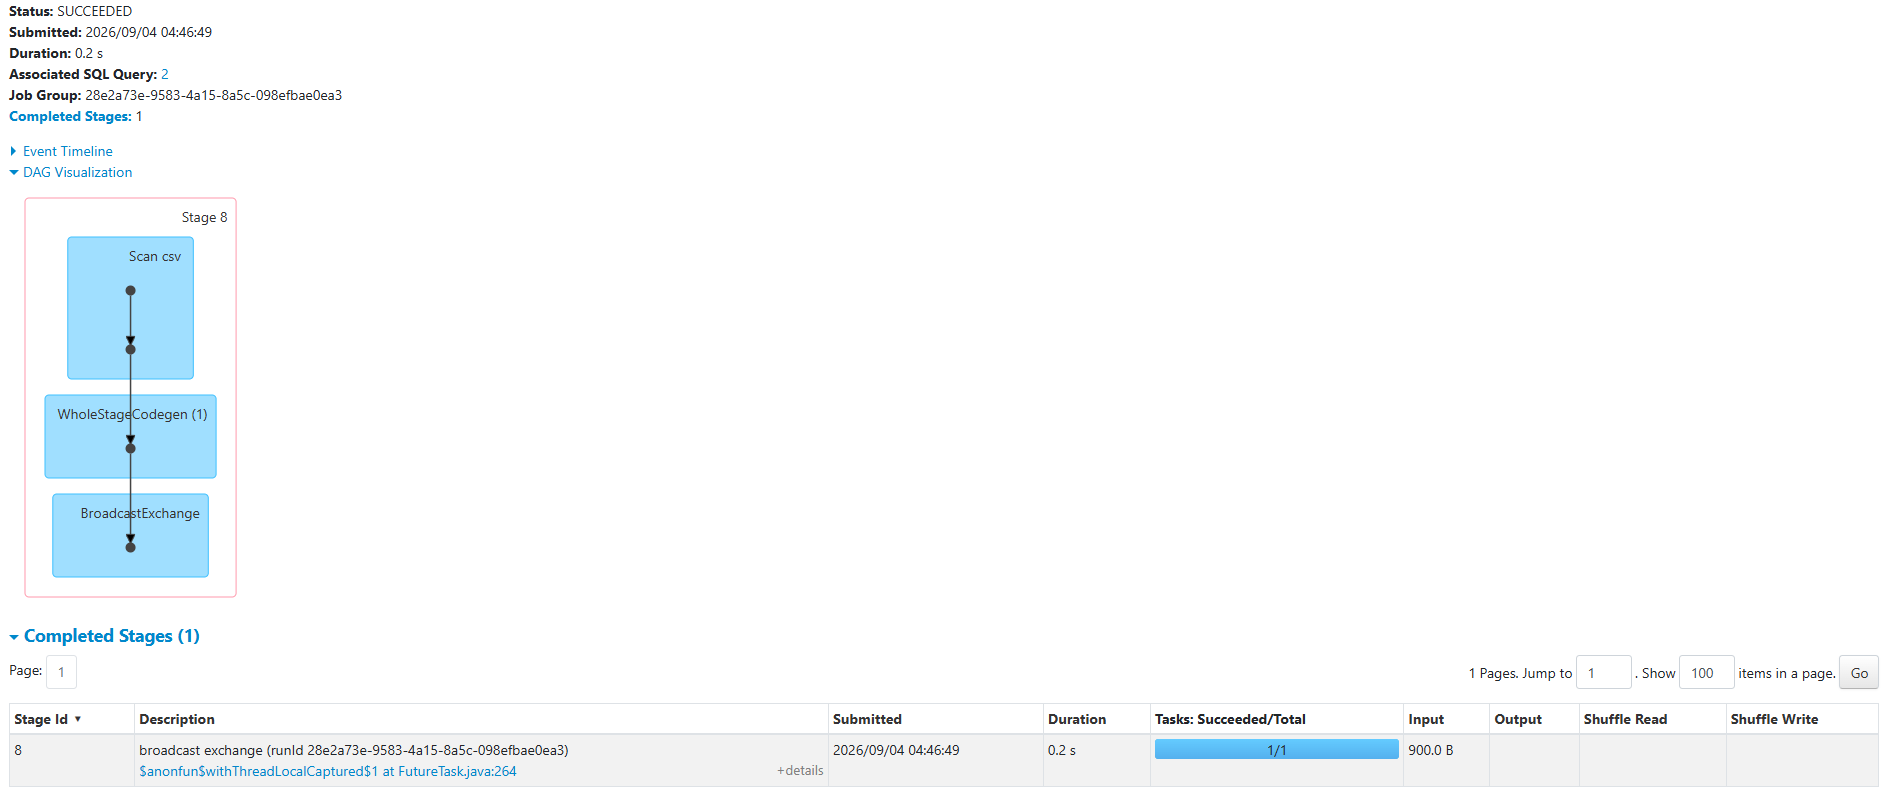

#### ☝️ Screenshot 2: Stage 8 Details — Fast Single-Task Broadcast Exchange

In the Stage 8 execution summary:
1. **Tasks: Succeeded/Total = 1/1:** Only **1 task** was needed to read the 900 bytes of `dept` and broadcast it.
2. **Duration: 0.2 s:** The entire broadcast stage completed in 200 ms.
3. **DAG Visualization for Stage 8:** Shows `Scan csv` passing through `WholeStageCodegen (1)` and into `BroadcastExchange`, making the broadcast table available locally on all cluster worker nodes.

---


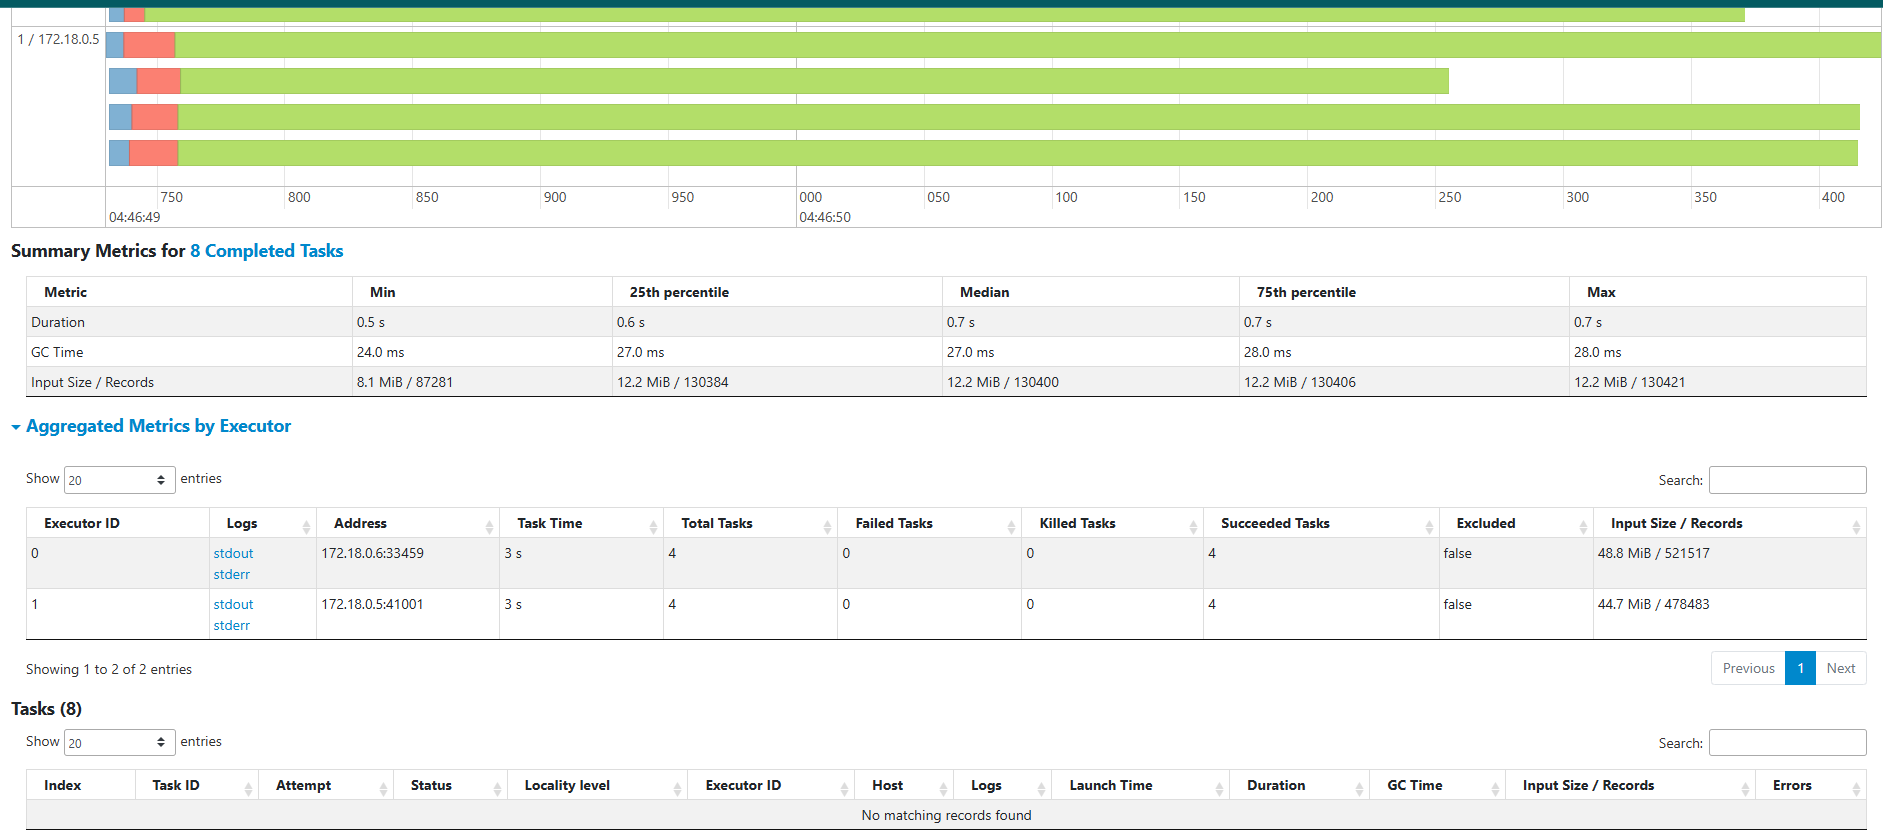

#### ☝️ Screenshot 3: Event Timeline & Summary Metrics — 8 Cores Streaming in Parallel

In the Event Timeline and Summary Metrics for the join execution:
1. **Full CPU Utilization (8 Parallel Tasks):** Because `spark.cores.max = 8`, Spark launched exactly **8 tasks** in parallel (visible as the 8 green bars across the timeline).
2. **Fast & Uniform Task Durations:**
   - **Min:** `0.5 s`
   - **Median:** `0.7 s`
   - **Max:** `0.7 s`
3. **No Shuffle Metrics — Pure Streaming Input:**
   - Notice the metric header is **Input Size / Records** (each task reading ~12.2 MiB / ~130,400 records), **NOT** *Shuffle Read*.
   - Each task streams rows directly from the employee CSV and probes the local in-memory hash table.
   - Total records processed: `521,517 (Executor 0) + 478,483 (Executor 1) = 1,000,000 rows`.

---


## 📝 6. Summary: AQE Key Configurations & Decision Cheat Sheet

### Key AQE Configuration Properties

| Configuration Property | Default Value | Description |
|---|---|---|
| `spark.sql.adaptive.enabled` | `true` (Spark 3+) | Master switch for Adaptive Query Execution. |
| `spark.sql.adaptive.coalescePartitions.enabled` | `true` | When true, dynamically coalesces small shuffle partitions. |
| `spark.sql.adaptive.advisoryPartitionSizeInBytes` | `64MB` | Target partition size when coalescing or splitting. |
| `spark.sql.adaptive.coalescePartitions.minPartitionNum` | `defaultParallelism` | Minimum number of post-shuffle partitions after coalescing. |
| `spark.sql.adaptive.skewJoin.enabled` | `true` | When true, automatically optimizes skewed joins by splitting partitions. |
| `spark.sql.adaptive.skewJoin.skewedPartitionFactor` | `5` | Multiplier above the median partition size to qualify as skewed. |
| `spark.sql.adaptive.skewJoin.skewedPartitionThresholdInBytes` | `256MB` | Absolute minimum size in bytes for a partition to be considered skewed. |
| `spark.sql.autoBroadcastJoinThreshold` | `10MB` | Threshold below which AQE dynamically converts joins to broadcast joins. |

### When to Rely on AQE vs. Manual Optimization

| Feature / Scenario | Static Spark (Spark 2.x) | Adaptive Query Execution (Spark 3.x) |
|---|---|---|
| **Shuffle Partitions** | Fixed at 200 (`spark.sql.shuffle.partitions`), causing 100s of empty tasks. | Dynamically coalesced into optimal partition sizes (`advisoryPartitionSizeInBytes`). |
| **Data Skew** | Must write manual Salting logic (random salt UDF + Cartesian Cross Join). | Handled automatically by splitting skewed partitions at runtime. |
| **Join Strategy** | Statically chosen before execution; cannot adapt to filtered data. | Dynamically converts Sort-Merge Join to Broadcast Hash Join if intermediate data is small. |
| **Supported Workloads** | Batch & Streaming. | Batch DataFrames / SQL (Structured Streaming not yet supported). |

---
